# Statistical Analysis

It allows you to delve into normality, statistical tests, correlations and relevant variables.

## Loading libraries

In [5]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggplot') 

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from visualization_scripts import distribution_grapher, qq_grapher, boxplots_grapher, corrmap_calc
from eda_scripts import unique_values
from statistical_analysis import descriptive_statistics, summary_statistics, interpret_statistics

## Data Loading

In [6]:
## Dowload DataSet:

data = pd.read_csv(str(Paths.DATA_PROCESSED)+"/preprocess_data.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather  year  month  \
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012      1   
1  2012-01-02           10.9      10.6       2.8   4.5     rain  2012      1   
2  2012-01-03            0.8      11.7       7.2   2.3     rain  2012      1   
3  2012-01-04           20.3      12.2       5.6   4.7     rain  2012      1   
4  2012-01-05            1.3       8.9       2.8   6.1     rain  2012      1   

   day  
0    1  
1    2  
2    3  
3    4  
4    5  


## Statistical Summary

In [7]:
numerical_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']
df_num = data[numerical_columns]

In [8]:
df_num.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.205886
std,6.680194,7.349758,5.023004,1.344474
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,6.600000


In [9]:
resumen = summary_statistics(df_num)
print(resumen)

                count    media  mediana  moda  desviacion_estandar  minimo  \
precipitation  1461.0   3.0294      0.0   0.0               6.6802     0.0   
temp_max       1461.0  16.4391     15.6  11.1               7.3498    -1.6   
temp_min       1461.0   8.2348      8.3   6.1               5.0230    -7.1   
wind           1461.0   3.2059      3.0   2.6               1.3445     0.4   

                 q1    q3  maximo  asimetria  curtosis  
precipitation   0.0   2.8    55.9     3.5056   15.5222  
temp_max       10.6  22.2    35.6     0.2809   -0.6905  
temp_min        4.4  12.2    18.3    -0.2495   -0.6006  
wind            2.2   4.0     6.6     0.5642   -0.3302  


## Analisis de Normalidad

Pruebas de normalidad: Shapiro-Wilk, Kolmogorov-Smirnov o Anderson-Darling

- Visual:

- Histograma + curva normal

- Q-Q plots (gráficos de cuantiles)

### Hypothesis Testing
The Shapiro-Wilk test and the D'Agostino K-squared test are two of the most commonly used hypothesis tests for analyzing normality. In both, the null hypothesis is that the data come from a normal distribution.

### Shapiro-Wilk Test
The p-value of these tests indicates the probability of obtaining data similar to those observed if they truly come from a population with a normal distribution with the same mean and standard deviation. Therefore, if the p-value is less than a certain value (typically 0.05), then there is sufficient evidence to reject normality.

The Shapiro-Wilk test is not recommended when there are large amounts of data (more than 50) due to its high sensitivity to small deviations from normality.

In [10]:
# Shapiro-Wilk test
# ==============================================================================

for idx, column in enumerate(df_num):
    if df_num[column].count() < 50:
        print(f"SI cumple criterio de datos, Cantidad de datos = {df_num[column].count()}")
    else:
        print(f"NO cumple criterio de datos, Cantidad de datos = {df_num[column].count()}")

    shapiro_test = stats.shapiro(df_num[column])
    print(shapiro_test)
    print()

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.5205678306061179), pvalue=np.float64(1.1627273421175324e-52))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9802632635945632), pvalue=np.float64(2.8459439764287343e-13))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9837458888294452), pvalue=np.float64(9.109896771574584e-12))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9630330789514168), pvalue=np.float64(7.799634324676515e-19))



### Test D'Agostino-Pearson
A test that is not sensitive to ties is the D'Agostino-Pearson normality test.

This test is implemented in the dagoTest function of the fBasics package. It quantifies how different the sample's skewness and kurtosis (two statistical parameters related to the shape of the graph of the sample density function) are from those expected in a normal distribution, and summarizes this discrepancy in a p-value with the usual meaning.

To apply this test, the sample size must be at least 20.

Therefore, we can only apply this test to the data sample corresponding to the Student's t distribution:

In [11]:
for idx, column in enumerate(df_num):    
    k2, p_value = stats.normaltest(df_num[column])
    print(f"Para datos {column}  ̣\nEstadístico = {k2}, p-value = {p_value}\n")

Para datos precipitation  ̣
Estadístico = 1106.3581061502698, p-value = 5.71991723813834e-241

Para datos temp_max  ̣
Estadístico = 90.89172197551865, p-value = 1.832792705405349e-20

Para datos temp_min  ̣
Estadístico = 61.37766489360388, p-value = 4.699042925532965e-14

Para datos wind  ̣
Estadístico = 77.61072616887533, p-value = 1.4029588861655434e-17



### Conclusion of normality analysis

There are no statistical indicators that establish the existence of normality in the data analyzed or, in other words, there is significant evidence of non-normality.

## Correlation Analysis

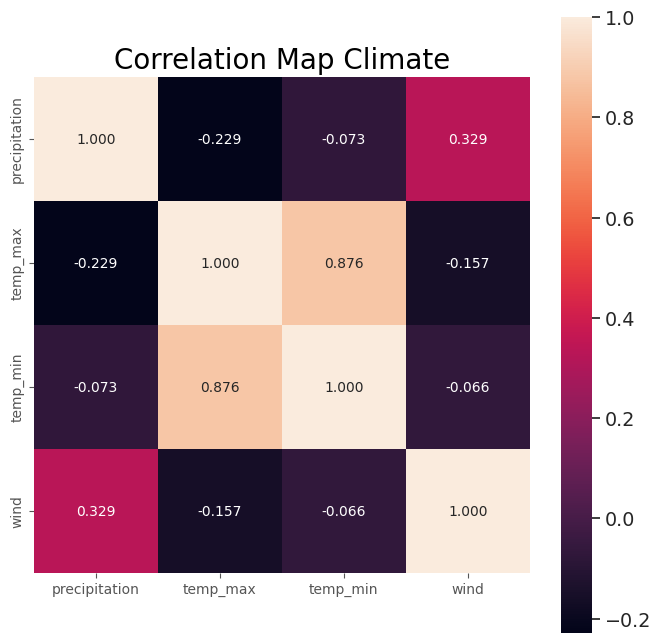

In [12]:
corrmap_calc(df_num,n_decimal = 3, title_graph = [True,"Correlation Map Climate",20] )


In [33]:
uniqueval_df = pd.DataFrame(unique_values(data[['weather']])[0])["Un_Value weather"]
print(uniqueval_df)

0       rain
1        sun
2        fog
3    drizzle
4       snow
Name: Un_Value weather, dtype: object


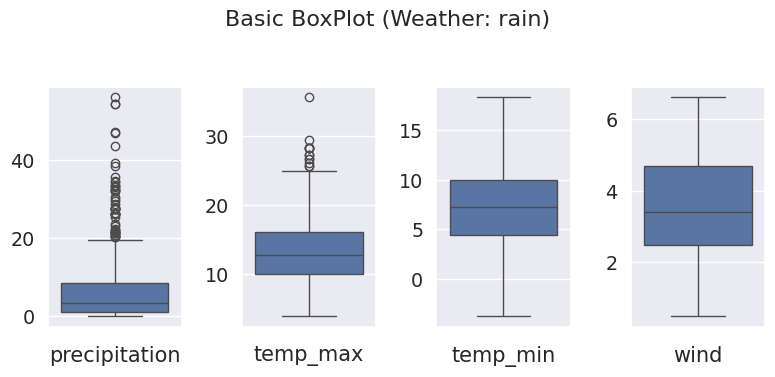

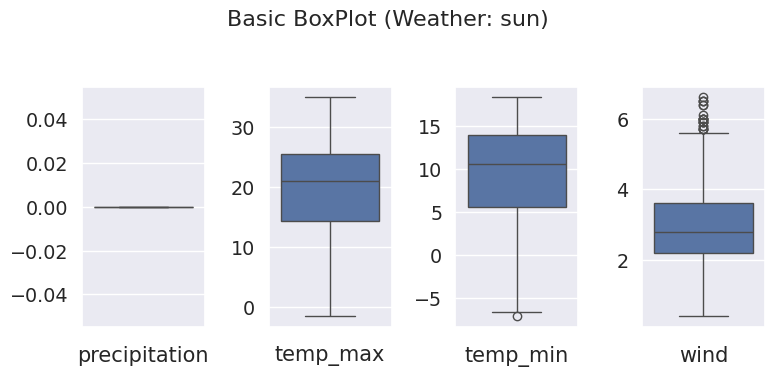

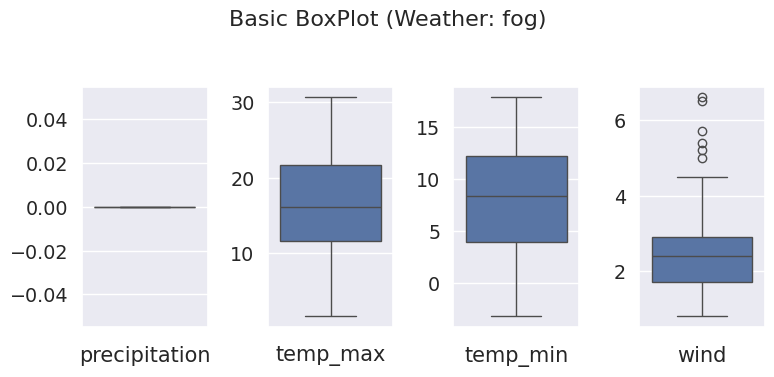

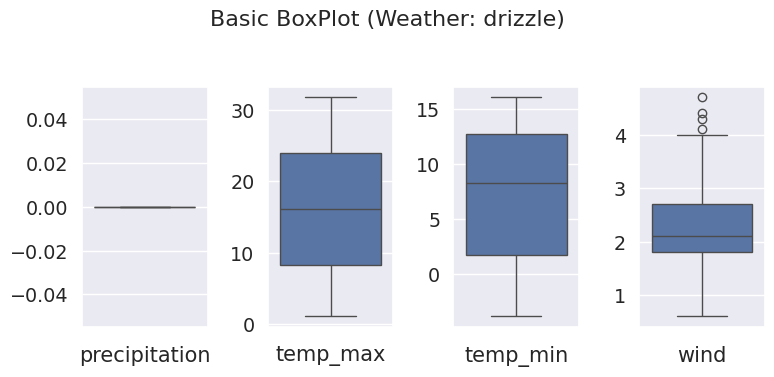

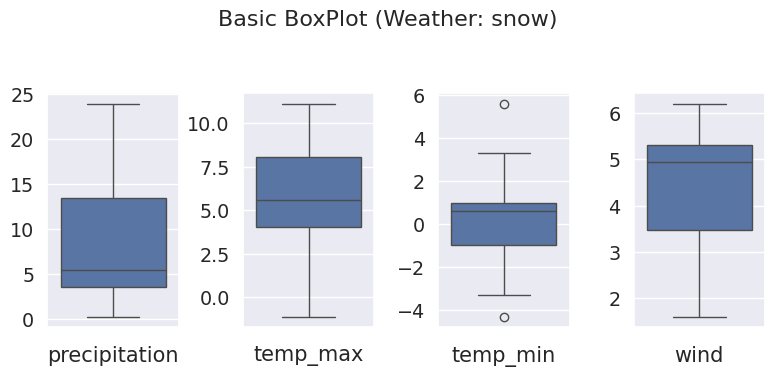

In [30]:
for i in uniqueval_df:
    df_vars = data[data['weather'] == i][['precipitation', 'temp_max', 'temp_min', 'wind']]
    boxplots_grapher(df_vars, [8,4], f"Basic BoxPlot (Weather: {i})")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def realizar_anova_completo(df, variable_numerica, variable_categorica):
    """
    Realiza análisis ANOVA completo con visualizaciones explicativas.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos
    variable_numerica : str
        Nombre de la variable numérica (dependiente)
    variable_categorica : str
        Nombre de la variable categórica (independiente)
    
    Returns:
    --------
    dict
        Diccionario con resultados del ANOVA
    """
    
    print("="*60)
    print(f"ANÁLISIS ANOVA: {variable_numerica} vs {variable_categorica}")
    print("="*60)
    
    # 1. Preparar datos
    grupos = []
    categorias = df[variable_categorica].unique()
    
    for categoria in categorias:
        grupo = df[df[variable_categorica] == categoria][variable_numerica]
        grupos.append(grupo)
    
    # 2. Estadísticas descriptivas por grupo
    print("\n📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:")
    print("-" * 50)
    
    estadisticas = df.groupby(variable_categorica)[variable_numerica].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(4)
    
    print(estadisticas)
    
    # 3. Realizar ANOVA
    print(f"\n🔍 PRUEBA ANOVA DE UNA VÍA:")
    print("-" * 50)
    
    f_stat, p_value = stats.f_oneway(*grupos)
    
    print(f"Estadístico F: {f_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Interpretación
    alpha = 0.05
    print(f"\nInterpretación (α = {alpha}):")
    if p_value < alpha:
        print("✅ RECHAZAMOS H₀: Hay diferencias significativas entre grupos")
        print("   Las medias de los grupos son estadísticamente diferentes")
    else:
        print("❌ NO RECHAZAMOS H₀: No hay diferencias significativas entre grupos")
        print("   Las medias de los grupos son estadísticamente similares")
    
    # 4. Verificar supuestos
    print(f"\n🔧 VERIFICACIÓN DE SUPUESTOS:")
    print("-" * 50)
    
    # Supuesto de normalidad (Shapiro-Wilk para cada grupo)
    print("1. Normalidad por grupo:")
    for i, categoria in enumerate(categorias):
        grupo = grupos[i]
        if len(grupo) < 5000:  # Shapiro-Wilk tiene limitaciones con muestras grandes
            _, p_norm = stats.shapiro(grupo)
            print(f"   {categoria}: p = {p_norm:.4f} {'✅' if p_norm > 0.05 else '❌'}")
    
    # Supuesto de homocedasticidad (Levene)
    _, p_levene = stats.levene(*grupos)
    print(f"2. Homocedasticidad (Levene): p = {p_levene:.4f} {'✅' if p_levene > 0.05 else '❌'}")
    
    # 5. Tamaño del efecto (Eta cuadrado)
    # SS_between / SS_total
    grand_mean = df[variable_numerica].mean()
    ss_between = sum([len(grupo) * (grupo.mean() - grand_mean)**2 for grupo in grupos])
    ss_total = sum([(x - grand_mean)**2 for x in df[variable_numerica]])
    eta_squared = ss_between / ss_total
    
    print(f"\n📏 TAMAÑO DEL EFECTO:")
    print("-" * 50)
    print(f"Eta² = {eta_squared:.4f}")
    
    if eta_squared < 0.01:
        efecto = "Muy pequeño"
    elif eta_squared < 0.06:
        efecto = "Pequeño"
    elif eta_squared < 0.14:
        efecto = "Moderado"
    else:
        efecto = "Grande"
    
    print(f"Interpretación: {efecto}")
    
    # 6. Crear visualizaciones
    crear_visualizaciones_anova(df, variable_numerica, variable_categorica)
    
    # Retornar resultados
    return {
        'f_statistic': f_stat,
        'p_value': p_value,
        'eta_squared': eta_squared,
        'estadisticas_grupo': estadisticas,
        'significativo': p_value < alpha
    }

def crear_visualizaciones_anova(df, var_num, var_cat):
    """
    Crea visualizaciones explicativas para el análisis ANOVA.
    """
    
    # Configurar subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis ANOVA: {var_num} vs {var_cat}', fontsize=16, fontweight='bold')
    
    # 1. Box Plot
    sns.boxplot(data=df, x=var_cat, y=var_num, ax=axes[0,0])
    axes[0,0].set_title('Box Plot - Distribución por Grupo')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Violin Plot
    sns.violinplot(data=df, x=var_cat, y=var_num, ax=axes[0,1])
    axes[0,1].set_title('Violin Plot - Densidad por Grupo')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Histograma superpuesto
    for categoria in df[var_cat].unique():
        datos = df[df[var_cat] == categoria][var_num]
        axes[1,0].hist(datos, alpha=0.7, label=categoria, bins=20)
    
    axes[1,0].set_title('Histogramas Superpuestos')
    axes[1,0].set_xlabel(var_num)
    axes[1,0].set_ylabel('Frecuencia')
    axes[1,0].legend()
    
    # 4. Gráfico de medias con intervalos de confianza
    medias = df.groupby(var_cat)[var_num].mean()
    errores = df.groupby(var_cat)[var_num].sem() * 1.96  # IC 95%
    
    x_pos = range(len(medias))
    axes[1,1].bar(x_pos, medias, yerr=errores, capsize=5, alpha=0.7)
    axes[1,1].set_title('Medias con Intervalos de Confianza 95%')
    axes[1,1].set_xlabel(var_cat)
    axes[1,1].set_ylabel(f'Media de {var_num}')
    axes[1,1].set_xticks(x_pos)
    axes[1,1].set_xticklabels(medias.index, rotation=45)
    
    # Ajustar diseño
    plt.tight_layout()
    plt.show()

def anova_post_hoc(df, variable_numerica, variable_categorica):
    """
    Realiza análisis post-hoc (Tukey HSD) si el ANOVA es significativo.
    """
    from scipy.stats import tukey_hsd
    
    print("\n🔍 ANÁLISIS POST-HOC (Tukey HSD):")
    print("-" * 50)
    
    # Preparar datos para Tukey HSD
    grupos = []
    categorias = df[variable_categorica].unique()
    
    for categoria in categorias:
        grupo = df[df[variable_categorica] == categoria][variable_numerica]
        grupos.append(grupo)
    
    # Realizar Tukey HSD
    try:
        resultado_tukey = tukey_hsd(*grupos)
        
        print("Comparaciones pareadas:")
        print(f"{'Grupo 1':<15} {'Grupo 2':<15} {'Diferencia':<12} {'p-value':<10} {'Significativo'}")
        print("-" * 70)
        
        for i in range(len(categorias)):
            for j in range(i+1, len(categorias)):
                p_val = resultado_tukey.pvalue[i, j]
                diff = abs(grupos[i].mean() - grupos[j].mean())
                sig = "✅" if p_val < 0.05 else "❌"
                
                print(f"{categorias[i]:<15} {categorias[j]:<15} {diff:<12.4f} {p_val:<10.4f} {sig}")
    
    except Exception as e:
        print(f"Error en análisis post-hoc: {e}")
        print("Puedes usar otros métodos como Bonferroni o realizar t-tests pareados")


ANÁLISIS ANOVA: wind vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count    mean  median     std     min      max
weather                                                
drizzle    303  4.0473  3.2990  2.6345  0.1817  13.3545
fog        283  3.9158  3.4128  2.7328  0.2730  17.7617
rain       269  3.8470  2.9936  2.9287  0.1131  16.9424
snow       317  3.6937  3.1828  2.6130  0.0652  13.3265
sun        289  4.0558  3.3593  3.0466  0.1492  18.7484

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 0.8920
p-value: 0.4679

Interpretación (α = 0.05):
❌ NO RECHAZAMOS H₀: No hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente similares

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   snow: p = 0.0000 ❌
   drizzle: p = 0.0000 ❌
   sun: p = 0.0000 ❌
   rain: p = 0.0000 ❌
   fog: p = 0.0000

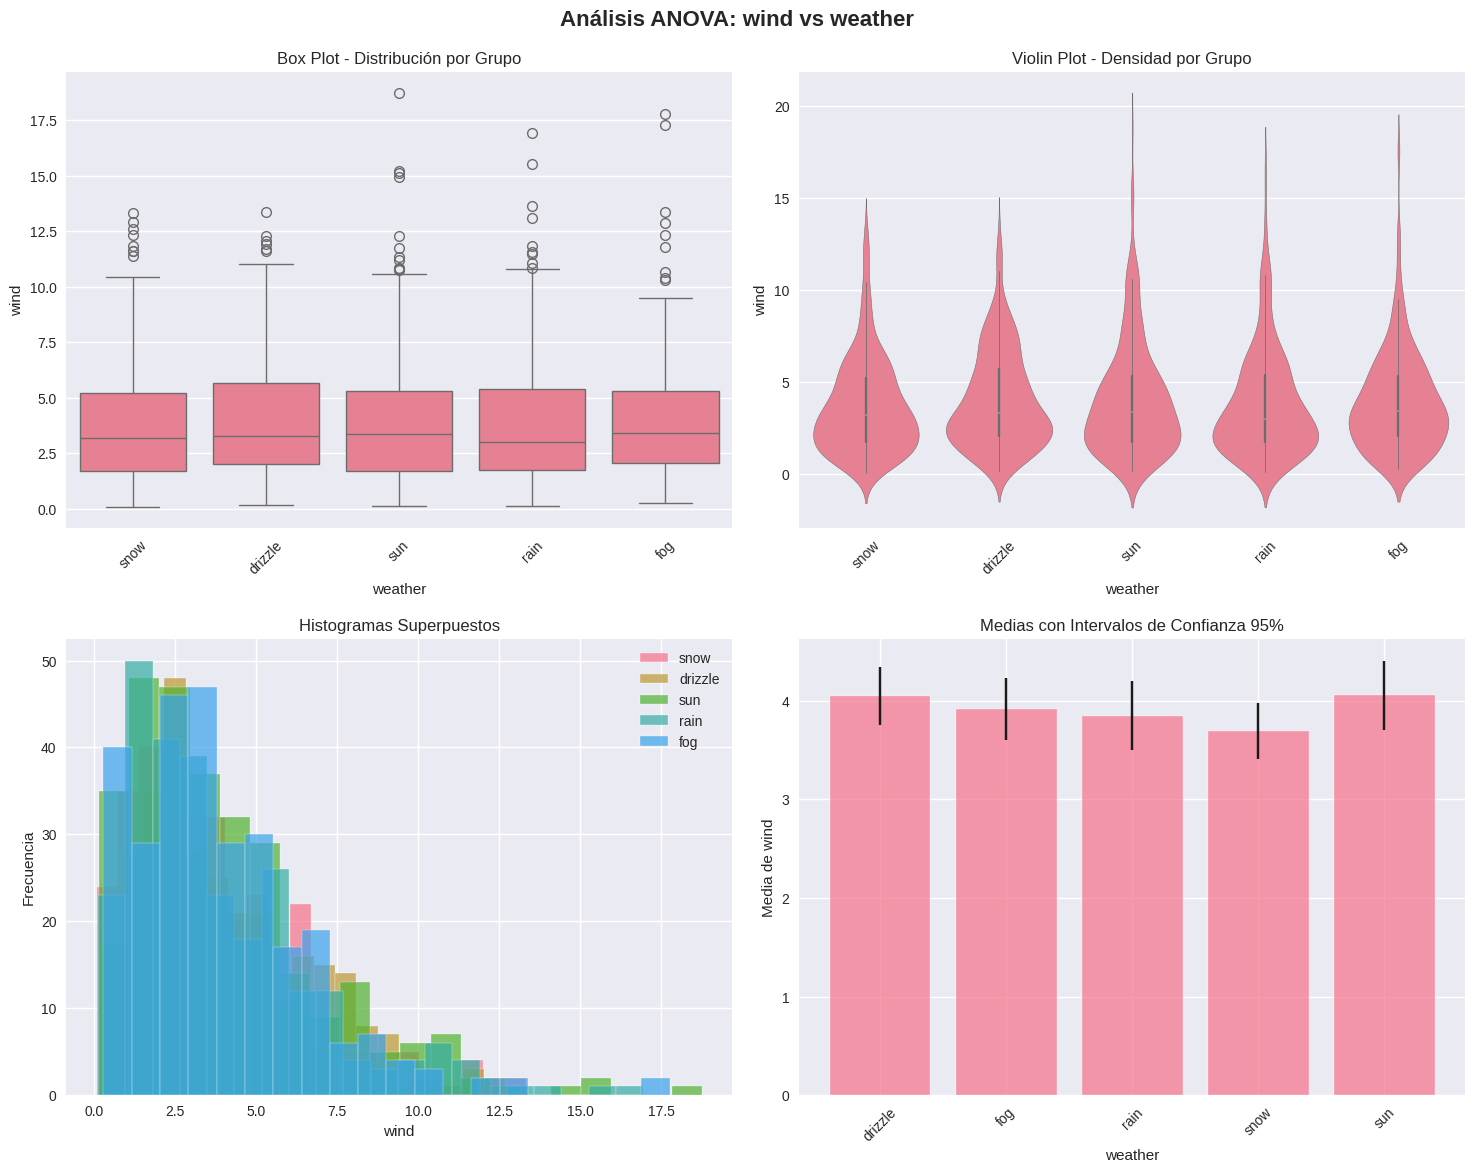

In [36]:
resultados = realizar_anova_completo(df_vars, 'wind', 'weather')

ANÁLISIS ANOVA: temp_max vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count     mean   median     std     min      max
weather                                                  
drizzle    303  19.8188  20.0439  7.5146 -0.4669  41.3055
fog        283  19.2284  19.7525  7.9272 -2.9703  41.7276
rain       269  19.7533  19.9492  8.4482 -3.1062  41.5003
snow       317  19.6640  19.2706  7.9608 -7.7714  41.8469
sun        289  20.4103  21.2032  7.6805 -2.1885  41.0738

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 0.8240
p-value: 0.5098

Interpretación (α = 0.05):
❌ NO RECHAZAMOS H₀: No hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente similares

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   snow: p = 0.8317 ✅
   drizzle: p = 0.5230 ✅
   sun: p = 0.5564 ✅
   rain: p = 0.5528 ✅


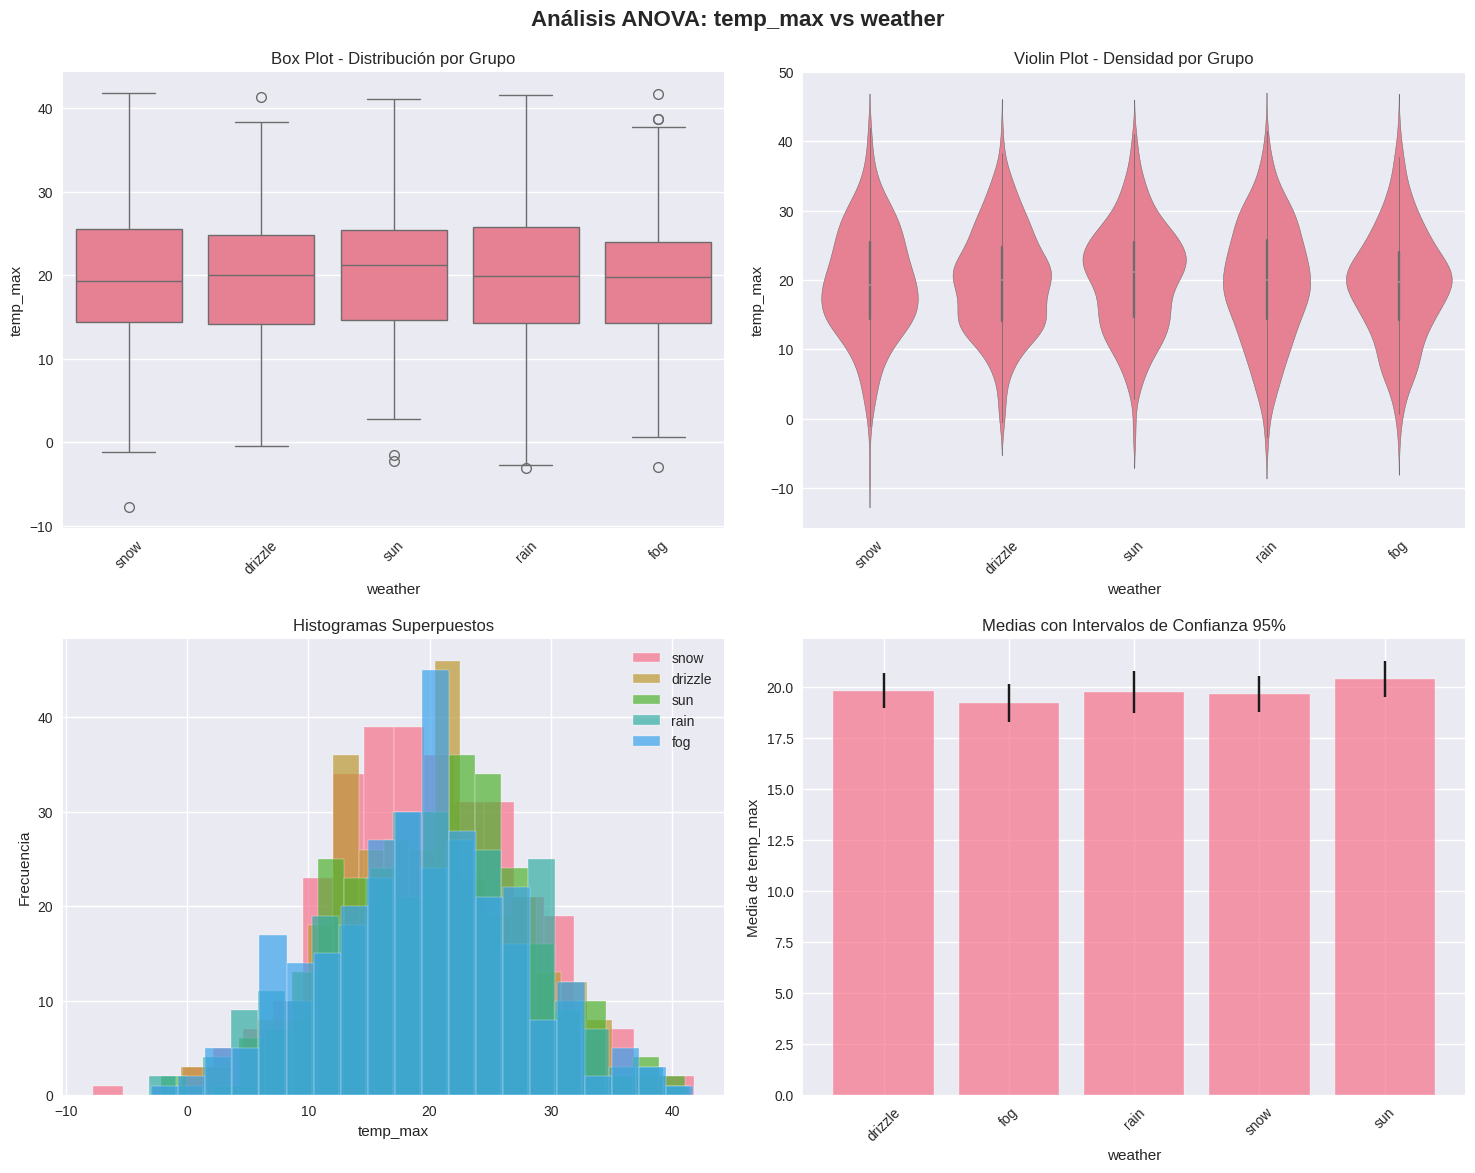

In [38]:
resultados = realizar_anova_completo(df_vars, 'temp_max', 'weather')

ANÁLISIS ANOVA: temp_min vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count     mean   median     std     min      max
weather                                                  
drizzle    303   9.4845   9.0012  6.0649 -9.9485  28.3717
fog        283  10.6177  10.4553  5.8078 -5.9860  26.1080
rain       269  10.3629  10.1681  5.7911 -4.9910  25.8012
snow       317  10.0473   9.6120  6.1137 -7.3994  25.4194
sun        289   9.7607   9.9344  5.7309 -3.9317  26.5959

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 1.7066
p-value: 0.1460

Interpretación (α = 0.05):
❌ NO RECHAZAMOS H₀: No hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente similares

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   snow: p = 0.1372 ✅
   drizzle: p = 0.1095 ✅
   sun: p = 0.7562 ✅
   rain: p = 0.5532 ✅


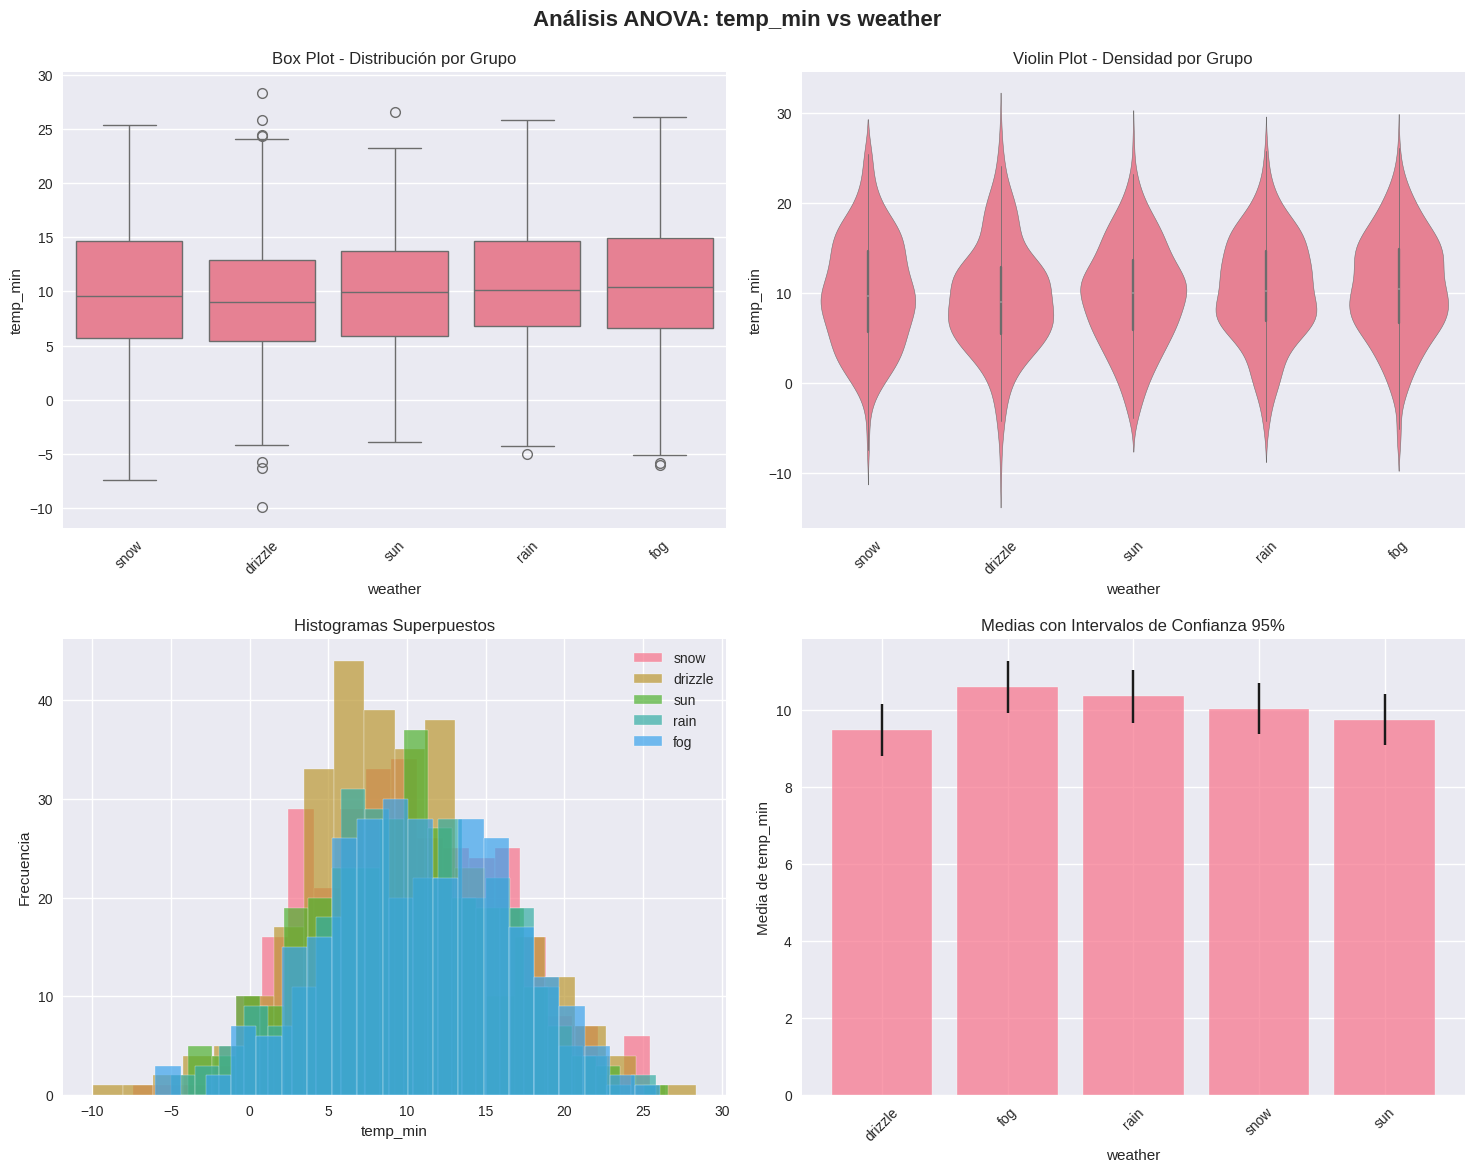

In [39]:
resultados = realizar_anova_completo(df_vars, 'temp_min', 'weather')

ANÁLISIS ANOVA: precipitation vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count    mean  median     std     min      max
weather                                                
drizzle    303  2.0063  1.3924  2.0163  0.0228  11.5362
fog        283  2.1355  1.4879  2.2840  0.0093  16.3449
rain       269  1.9687  1.3671  1.9659  0.0101  11.3897
snow       317  2.1049  1.5530  1.8923  0.0128   9.4589
sun        289  1.8380  1.2873  1.8629  0.0099  11.7031

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 1.0127
p-value: 0.3996

Interpretación (α = 0.05):
❌ NO RECHAZAMOS H₀: No hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente similares

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   snow: p = 0.0000 ❌
   drizzle: p = 0.0000 ❌
   sun: p = 0.0000 ❌
   rain: p = 0.0000 ❌
   fog: p

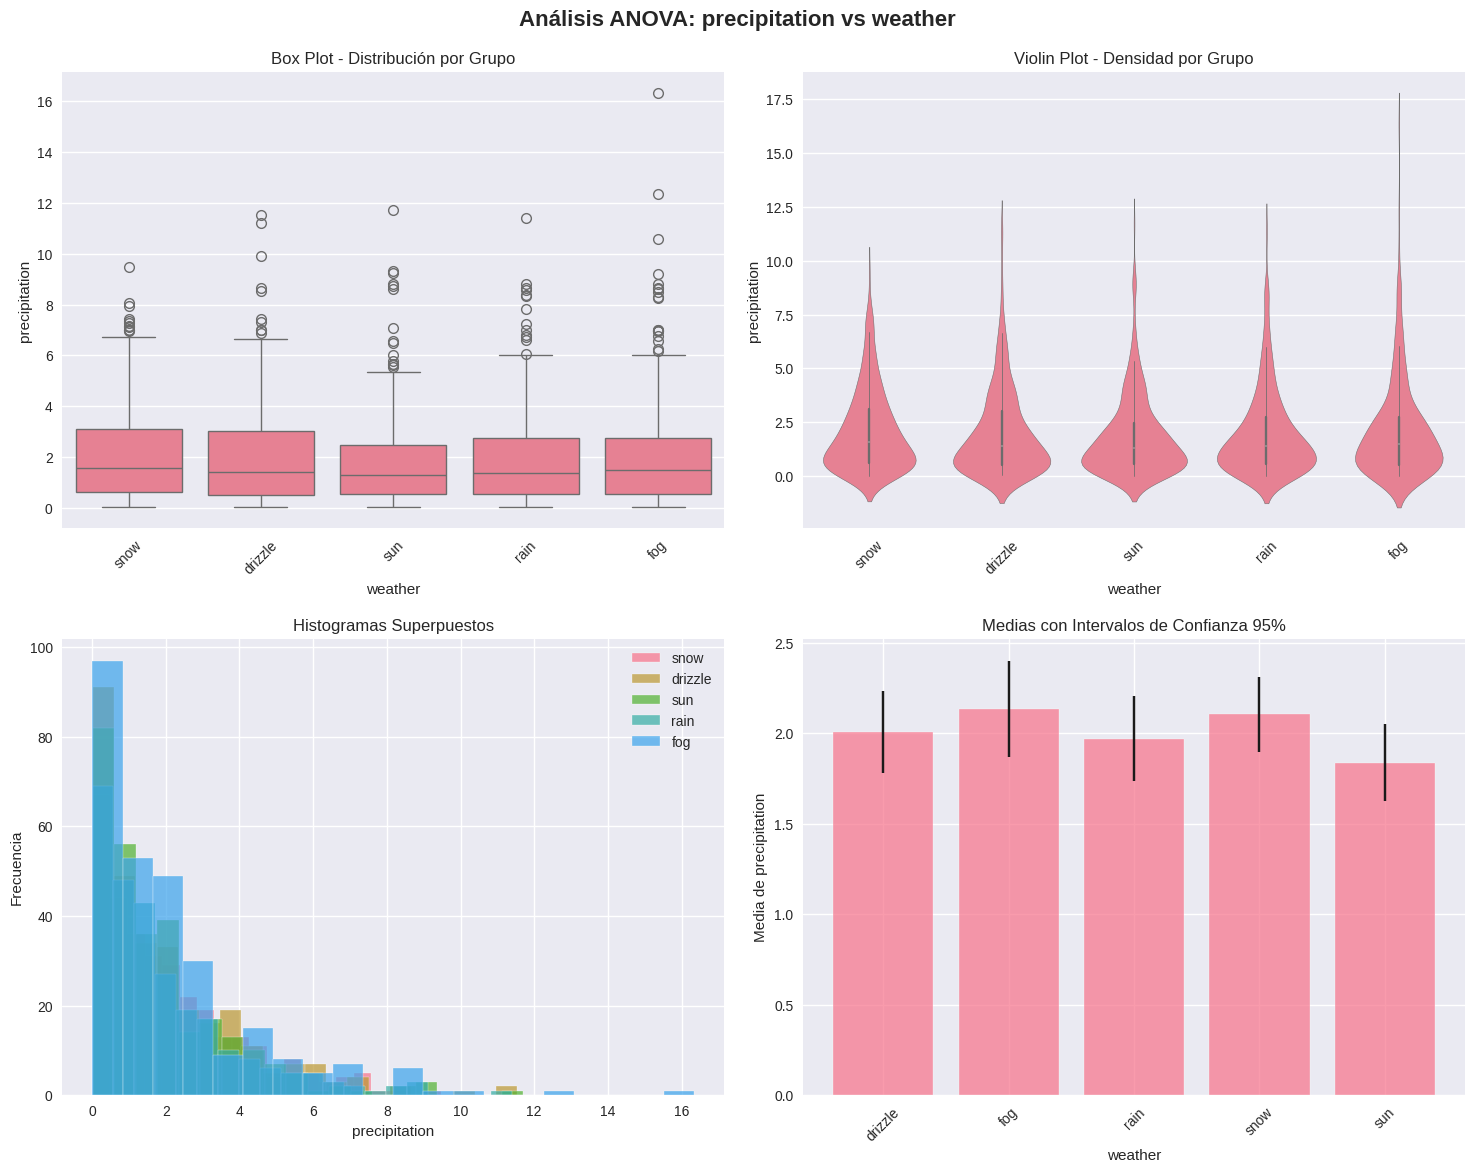

In [40]:
resultados = realizar_anova_completo(df_vars, 'precipitation', 'weather')